# 01 · EDA temporal e integridad de los datos

Qué se responde aquí:

1. ¿Las dos fuentes se integran sin perder ni duplicar filas?
2. ¿Cómo cambian el fraude, el volumen y los faltantes a lo largo de 182 días?
3. ¿Las features de historial son realmente causales?

El notebook **no** recalcula nada pesado: lee el Parquet y los manifests que
produjo `fraud-adaptive data prepare`.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent          # el notebook puede abrirse desde notebooks/
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fraud_adaptive.pipeline import load_configs
from fraud_adaptive.tracking import read_json

CONFIGS = load_configs(ROOT / "configs")
RUN_DIR = ROOT / CONFIGS["base"]["paths"]["runs"] / "principal"
REPORTS = ROOT / CONFIGS["base"]["paths"]["reports"]

MANIFEST = read_json(ROOT / CONFIGS["base"]["paths"]["manifests"] / "sources.json")
DATA_SOURCE = MANIFEST.get("data_source", "desconocido")

if DATA_SOURCE == "sintetico_sustituto":
    print("AVISO: los datos son un SUSTITUTO SINTETICO. Ninguna cifra describe IEEE-CIS.")
else:
    print("Datos: IEEE-CIS Fraud Detection (particion train).")
print("Run:", RUN_DIR)

AVISO: los datos son un SUSTITUTO SINTETICO. Ninguna cifra describe IEEE-CIS.
Run: C:\Users\25por\OneDrive\Desktop\utec\planifica\PLANIFICA_PROYECTO01\runs\principal


## 1. Auditoría del join

El número de filas debe ser invariante: un join many-to-many las multiplicaría en silencio.

In [2]:
join = MANIFEST["join"]
esquema = MANIFEST["esquema"]

print(f"Transacciones : {esquema['n_transactions']:,} filas x {esquema['n_columns_transactions']} columnas")
print(f"Identidad     : {esquema['n_identity']:,} filas x {esquema['n_columns_identity']} columnas")
print(f"Prevalencia   : {esquema['prevalencia']:.4f}")
print()
for clave, valor in join.items():
    print(f"  {clave:<28} {valor}")

assert join["filas_invariantes"], "el join alteró el número de filas"
print("\nOK: el join es uno-a-uno y preserva todas las transacciones.")

Transacciones : 581,972 filas x 394 columnas
Identidad     : 139,843 filas x 41 columnas
Prevalencia   : 0.0352

  filas_antes                  581972
  filas_despues                581972
  filas_invariantes            True
  ids_identidad                139843
  ids_identidad_huerfanos      0
  cobertura_identidad          0.24029162915054333
  columnas_identidad           40
  nota                         La ausencia de identidad es informativa (has_identity), no se imputa ni se descarta la fila.

OK: el join es uno-a-uno y preserva todas las transacciones.


## 2. Los dos relojes

`TransactionDT` es un **delta en segundos**, no una fecha. La hora derivada es relativa a un origen desconocido: sirve como ciclo de 24 h, no identifica hora local ni día laboral.

In [3]:
eventos = pd.read_parquet(ROOT / CONFIGS["base"]["paths"]["processed"] / "eventos.parquet")

print(f"Eventos: {len(eventos):,}   columnas: {eventos.shape[1]}")
print(f"Días cubiertos: {eventos['dia'].min()} a {eventos['dia'].max()}")
print(f"Transacciones por día (mediana): {int(eventos.groupby('dia').size().median()):,}")
eventos[["TransactionDT", "s_rel", "dia", "semana", "hora"]].head()

Eventos: 581,972   columnas: 473
Días cubiertos: 0 a 181
Transacciones por día (mediana): 3,187


,TransactionDT,s_rel,dia,semana,hora
0,88303,0,0,0,0
1,89109,806,0,0,0
2,90358,2055,0,0,0
3,90397,2094,0,0,0
4,90431,2128,0,0,0


## 3. Perfil semanal con intervalos de Wilson

Con prevalencias del ~3,5 % y miles de filas por semana, el intervalo de Wald puede salirse de [0,1]; Wilson no.

In [4]:
from fraud_adaptive.data import weekly_profile

semanal = weekly_profile(eventos, target="isFraud", amount_col="TransactionAmt")
semanal[["semana", "n", "fraudes", "prevalencia", "wilson_low", "wilson_high",
         "cobertura_identidad"]].round(4).head(12)

,semana,n,fraudes,prevalencia,wilson_low,wilson_high,cobertura_identidad
0,0,22403,852,0.0380,0.0356,0.0406,0.2390
1,1,22492,833,0.0370,0.0346,0.0396,0.2434
2,2,22314,723,0.0324,0.0302,0.0348,0.2380
3,3,22372,738,0.0330,0.0307,0.0354,0.2383
4,4,22378,817,0.0365,0.0341,0.0390,0.2425
5,5,22380,841,0.0376,0.0352,0.0402,0.2408
6,6,22383,734,0.0328,0.0305,0.0352,0.2351
7,7,22255,754,0.0339,0.0316,0.0363,0.2408
8,8,22337,839,0.0376,0.0351,0.0401,0.2438
9,9,22468,840,0.0374,0.0350,0.0399,0.2418


## 4. Faltantes por familia

IEEE-CIS tiene cientos de columnas anónimas. La familia (V, C, D, M, id_, card, addr) es la unidad interpretable.

In [5]:
from fraud_adaptive.data import missingness_by_family

missingness_by_family(eventos).round(3)

,familia,n_columnas,missing_medio,missing_min,missing_max,columnas_sobre_95pct
0,C,14,0.000,0.000,0.000,0
1,D,15,0.490,0.104,0.875,0
2,M,9,0.300,0.181,0.421,0
3,V,339,0.429,0.020,0.762,0
4,addr,2,0.000,0.000,0.000,0
5,card,20,0.076,0.000,0.959,1
6,id_,38,0.803,0.779,0.813,0
7,otras,36,0.428,0.000,0.930,0


## 5. Anomalías antes de culpar al drift

Un hueco de captura o un pico de duplicados explican una alerta mejor que un cambio de comportamiento. Se descartan primero.

In [6]:
from fraud_adaptive.data import detect_anomalies

print(json.dumps(detect_anomalies(eventos, amount_col="TransactionAmt", target="isFraud"),
                 indent=2, ensure_ascii=False))

{
  "dias_cubiertos": 182,
  "dias_faltantes": [],
  "n_dias_faltantes": 0,
  "volumen_diario_mediano": 3187.5,
  "dias_volumen_bajo": [],
  "dias_volumen_alto": [],
  "monto_p99": 461.31929,
  "n_montos_extremos": 3,
  "n_duplicados_exactos": 2,
  "prevalencia_global": 0.03523537214848824
}


## 6. Calidad de los proxies de entidad

Un proxy agrupa comportamiento; **no identifica a una persona**. Se mide en vez de asumirse.

In [7]:
for nombre, calidad in MANIFEST["features"]["proxies"].items():
    print(f"{nombre}:")
    for clave, valor in calidad.items():
        if clave != "nota":
            print(f"    {clave:<30} {valor}")
    print()

card:
    proxy                          card_proxy
    n_entidades                    10613
    cobertura                      1.0
    eventos_por_entidad_medio      54.83576745500801
    eventos_por_entidad_p95        180.0
    entidades_con_un_evento        2043
    fraccion_singleton             0.19249976443983793
    top1_share                     0.0003763067638992941

device:
    proxy                          device_proxy
    n_entidades                    2294
    cobertura                      0.24029162915054333
    eventos_por_entidad_medio      60.96033129904097
    eventos_por_entidad_p95        43.34999999999991
    entidades_con_un_evento        696
    fraccion_singleton             0.30340017436791633
    top1_share                     0.3857254206503007



## 7. Causalidad: la prueba que importa

Las features se emiten **antes** de actualizar el estado. La comprobación decisiva
es que añadir un evento futuro no mueva ninguna fila anterior.

In [8]:
from fraud_adaptive.features import prepare_features

base = pd.DataFrame({
    "TransactionID": [1, 2, 3], "TransactionDT": [100, 200, 300],
    "TransactionAmt": [10.0, 20.0, 30.0],
    "card1": ["A"]*3, "card2": [1]*3, "card3": [1]*3, "card4": ["visa"]*3,
    "card5": [1]*3, "card6": ["debit"]*3, "addr1": [1]*3,
    "DeviceType": ["desktop"]*3, "DeviceInfo": ["Windows"]*3,
    "has_identity": [1]*3, "isFraud": [0]*3,
})
con_futuro = pd.concat([base, base.iloc[[0]].assign(
    TransactionID=4, TransactionDT=400, TransactionAmt=999999.0)], ignore_index=True)

a, _ = prepare_features(base)
b, _ = prepare_features(con_futuro)
# Solo las features numéricas de historial: `card_proxy` es la clave de entidad, texto.
cols = [c for c in a.columns
        if c.startswith("card_") and c != "card_proxy" and pd.api.types.is_numeric_dtype(a[c])]

iguales = np.allclose(a[cols].fillna(-1).to_numpy(), b[cols].head(3).fillna(-1).to_numpy())
print("Un evento futuro de monto extremo no altera las filas anteriores:", iguales)
assert iguales
a[["TransactionID", "card_cnt_expansivo", "card_cnt_24h", "card_amt_rezago"]]

Un evento futuro de monto extremo no altera las filas anteriores: True


,TransactionID,card_cnt_expansivo,card_cnt_24h,card_amt_rezago
0,1,0.0,0.0,NaN
1,2,1.0,1.0,10.0
2,3,2.0,2.0,20.0


## 8. Figura de EDA

Generada por `fraud-adaptive report build`.

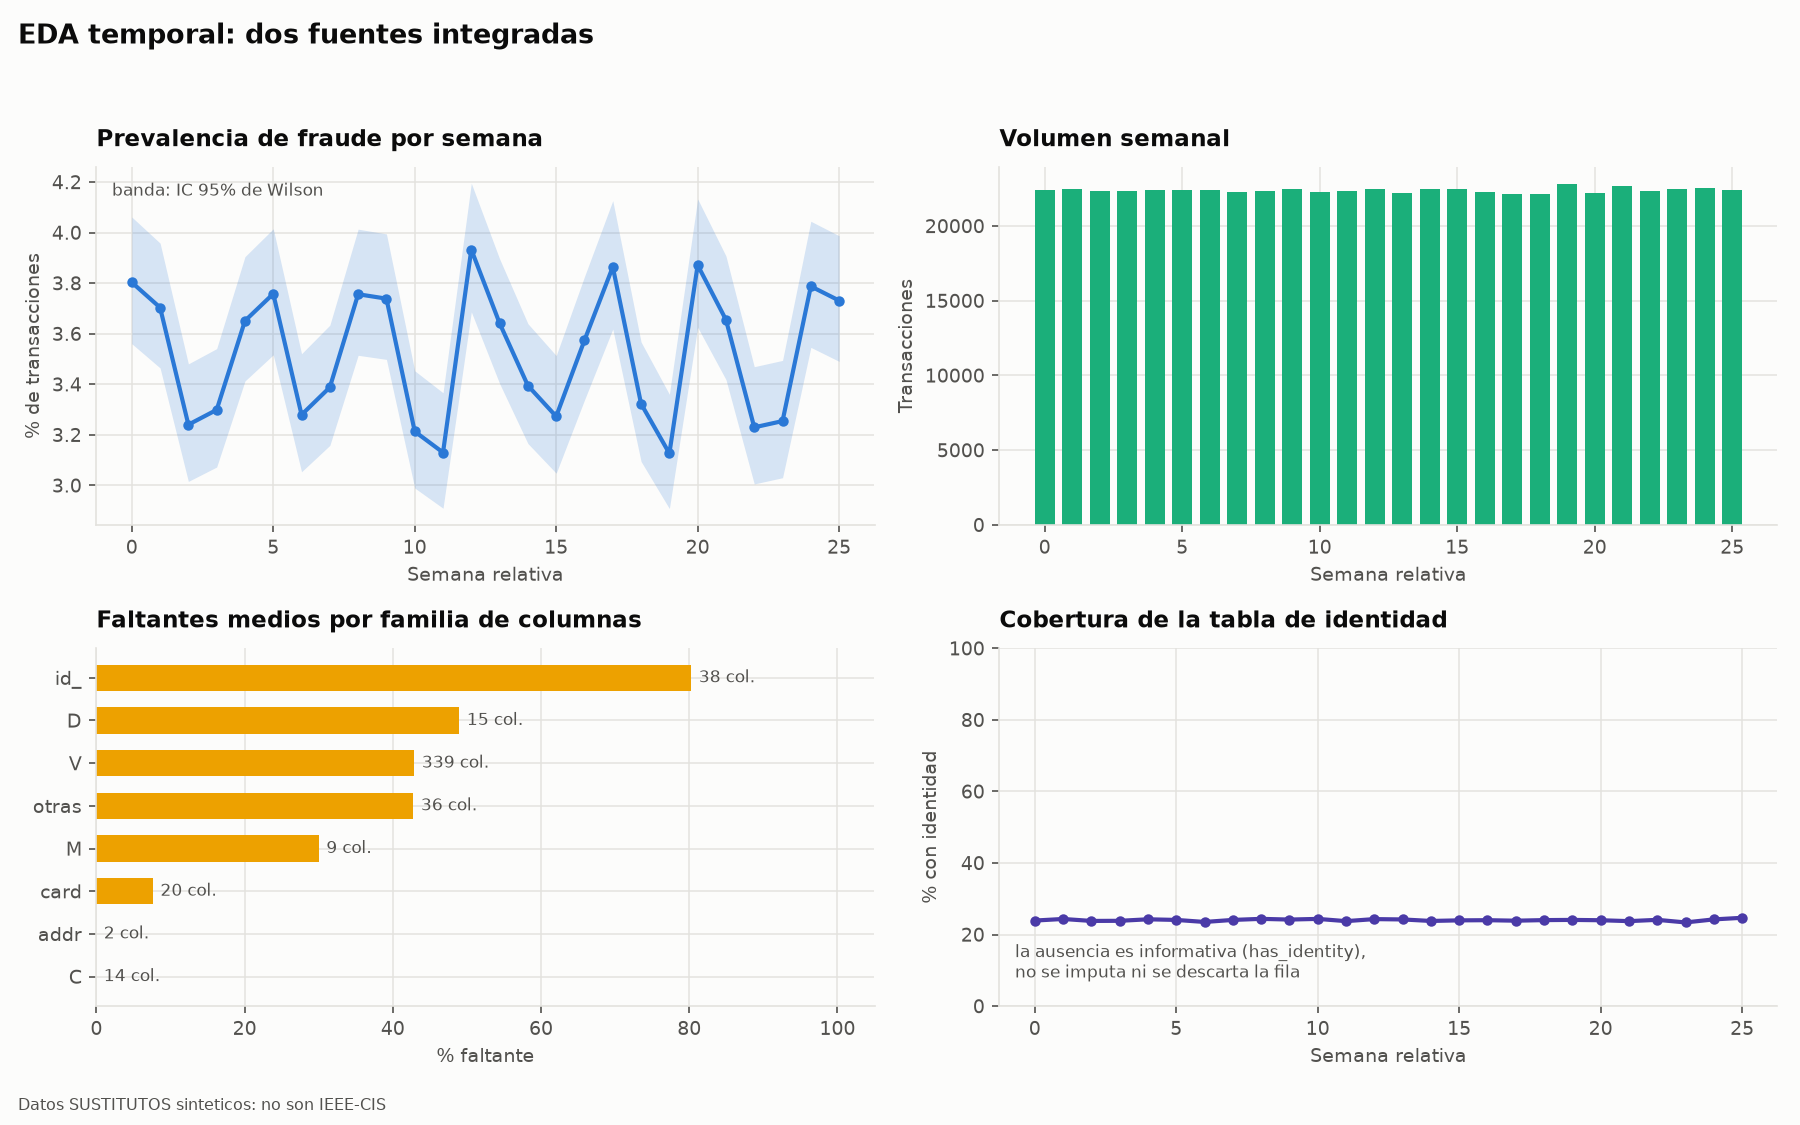

In [9]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS / "figures" / "eda_temporal.png")))